In [1]:
# Importació de les biblioteques bàsiques
import numpy as np
from scipy.fft import fft, ifft

##### 3 maneres diferents de presentar les gràfiques
# INLINE: Les gràfiques es pinten just a sota la cel·la que les genera, però no són interactives. 
#         Útil per crear un PDF autocontingut amb enunciat i resultats
#
# WIDGET: Similar a l'anterior però les gràfiques són interactives i redimensionables.
#         - Si obrim moltes gràfiques simultànies es pot queixer per manca de recursos
#         - Cal instal·lar el paquet 'ipympl' (no ve per defecte) per tal que funcioni
#
#     QT: Cada gràfica es crea en una finestra a part.
#         És l'opció més flexible però també dificulta documentar els resultats
#
# DESCOMENTEU UNA DE LES TRES OPCIONS
#%matplotlib inline
#%matplotlib widget 
#%matplotlib qt
import matplotlib.pyplot as plt


# Fem la mida per defecte dels plots una mica més gran
plt.rcParams['figure.figsize'] = [9.5, 6]
plt.rcParams['figure.dpi'] = 80

# Augmentem una mica el nombre de gràfics oberts permesos sense warning
plt.rcParams['figure.max_open_warning'] = 30


# Definim una funció per automatitzar el dibuix d'una seqüència conjuntament amb la seva DTFT
def pintaDTFT(x, N, fm=1, superposa_dtft=False):
    """
    
    Paràmetres
    ----------
    x   : Array NumPy 1-D de nombres reals 
          Seqüència d'entrada de la qual es vol calcular la DTFT
    N   : Enter
          Nombre de punts de la FFT. Normalment serà N > len(x)
    fm  : Enter (per defecte=1)
          Freqüència de mostratge (per pintar adequadament l'eix de freqüències)

    Retorna
    -------
    f : NumPy Array
        Vector de freqüències (longitud N)
    X : Vector de valors de la DTFT a les freqüències del vector f (longitud N)

    """
    
    fig, (ax1,ax2) = plt.subplots(2, 1, constrained_layout=True)

    # Gràfica de la seqüència
    ax1.stem(x)                        # Assumim que la separació entre punts val 1
    ax1.grid(True)
    ax1.set_title("Seqüència x[n] de L={}".format(L))
    ax1.set_ylabel("Amplitud")
    ax1.set_xlabel("Índex n")
    
    # Si hem de superposar la DTFT, calculem una FFT amb molts punts, que serà una bona aproximació a la DTFT
    if superposa_dtft:
        NDTFT = 4096
        DTFT = fft(x,NDTFT)
        fdtft = fm*np.arange(NDTFT)/NDTFT
        ax2.plot(fdtft,np.abs(DTFT),"0.8")

    # Gràfica de la Transformada de Fourier
    X = fft(x,N)                       # Càlcul de la DTFT (bé, només el seu valor en N punts) usant l'algorisme FFT
    f = fm*np.arange(N)/N              # Càlcul del vector de freqüències associat (N valors, de 0 a (N-1)/N)
    ax2.plot(f,np.abs(X),
             "C1o-" if N< 200 else "C1-",
             markersize=2.5,
             markerfacecolor="black",
             markeredgecolor="black")  # Pintem el mòdul de la FFT, unint els punts (negres) amb rectes (taronges, color "C1")
    ax2.set_xticks(fm*np.arange(21)/20)  # 20 ticks cada 0.05*fm
    ax2.grid(True)
    ax2.set_title("Transformada de Fourier X(F) amb N={}".format(N))
    ax2.set_ylabel("Amplitud")
    ax2.set_xlabel("Freqüència F")
    
    return f,X


Màxim pel cas N=L: 3.337373000804647 a F=0.2222222222222222
3.337373000804647 0.2222222222222222


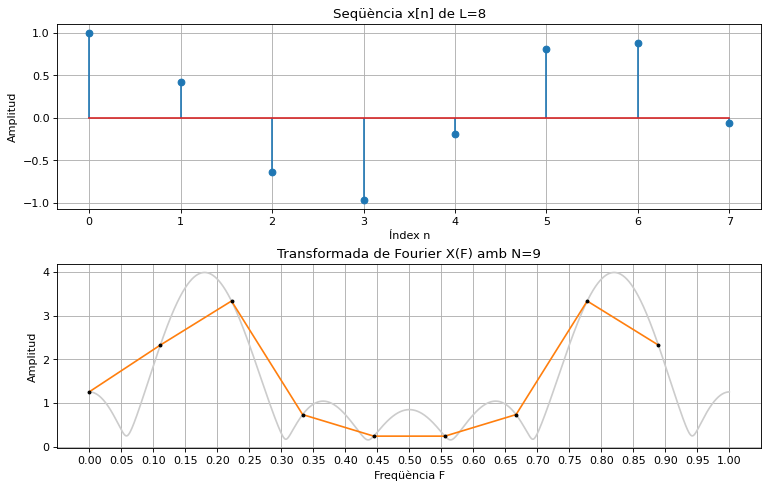

In [24]:
# Introduïu aquí el codi i executeu-lo

# Longitud de la seqüència
L  = 8
n  = np.arange(L)              # Vector d'índex per generar el cosinus

# Cas 1:
Fo = 0.18
x  = np.cos(2*np.pi*Fo*n)                          # Cosinus

# paràmetres de la DTFT, generació i representació gràfica
N = 9                           # Longitud de la FFT
f,X = pintaDTFT(x,N, superposa_dtft = True)

# Calculeu el valor del màxim i la freqüència a la que es dóna
Xmax = max(np.abs(X))
Fmax = f[np.argmax(np.abs(X))]
print("Màxim pel cas N=L: {} a F={}".format(Xmax, Fmax))

# # Cas 2:
# Fo = 0.18
# x  = np.cos(2*np.pi*Fo*n)                          # Cosinus

print(Xmax, Fmax)